# Attention Pattern Analysis

**Research Question:** Which attention heads in Layer 1 and Layer 2 are 
responsible for tracking modifier tokens ('twice', 'thrice') and action 
repetition counts, and how do their attention patterns differ between 
success and failure cases?

**Hypotheses:**
- H1: Certain heads attend strongly to modifier tokens during successful generation
- H2: Layer 2 Overwrite failures correspond to heads failing to attend to modifiers
- H3: Some heads track previously generated actions to count repetitions

**Dependencies & Setup**

In [1]:
import sys, os
root_path = os.path.abspath("..")
src_path = os.path.join(root_path, "src")
for path in [root_path, src_path]:
    if path not in sys.path:
        sys.path.append(root_path)

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from jaxtyping import Float, Int
from torch import Tensor
import circuitsvis as cv
from transformer_lens import HookedTransformer, HookedTransformerConfig

from config.config import Config
from src.data import SCANDataModule,SCANTokenizer
from src.model import Transformer

## 1. Setup & Load Model
**Goal:** Load trained model, data module, and failure cases from Notebook 01.

In [2]:
cfg = Config()
model = Transformer(cfg)
model.load_state_dict(torch.load("../results/model_final_small.pt"))


dm = SCANDataModule(cfg)
tokenizer = dm.tokenizer

import re
import pandas as pd

def parse_failure_log(filepath):
    """
    Parses SCAN failure logs and returns a list of dictionaries 
    with columns: splitname, command, target, pred.
    """
    # Regex breakdown:
    # \[(.*?)\] -> Captures everything inside the square brackets (splitname)
    # COMMAND:.*?IN:\s*(.*?)\s*OUT: -> Captures everything between IN: and OUT: (command)
    # TARGET:\s*(.*?)\s*\| -> Captures everything between TARGET: and the next | (target)
    # PRED:\s*(.*)$ -> Captures everything after PRED: to the end of the line (pred)
    pattern = re.compile(r"\[(.*?)\]\s*COMMAND:\s*(.*?)\s*\|\s*TARGET:\s*(.*?)\s*\|\s*PRED:\s*(.*)$")
    
    parsed_rows = []
    
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue  # Skip empty lines
                
            match = pattern.search(line)
            if match:
                splitname, command, target, pred = match.groups()
                
                parsed_rows.append({
                    "splitname": splitname,
                    "command": command.strip(),
                    "target": target.strip(),
                    "pred": pred.strip()
                })
                
    return parsed_rows

simple_data = parse_failure_log("../results/small_failure_cases_simple.txt")
length_data = parse_failure_log("../results/small_failure_cases_length.txt")
addprim_jump_data = parse_failure_log("../results/small_failure_cases_addprim_jump.txt")

all_failures = pd.DataFrame(simple_data + length_data + addprim_jump_data)
simple_failures = pd.DataFrame(simple_data)
length_failures = pd.DataFrame(length_data)
addprim_jump_failures = pd.DataFrame(addprim_jump_data)

simple_failures.head()

,splitname,command,target,pred
0,simple,<sos> IN: turn opposite right thrice and turn ...,I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_...,I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_...
1,simple,<sos> IN: look around right twice and turn lef...,I_TURN_RIGHT I_LOOK I_TURN_RIGHT I_LOOK I_TURN...,I_TURN_RIGHT I_LOOK I_TURN_RIGHT I_LOOK I_TURN...
2,simple,<sos> IN: jump around left thrice and run righ...,I_TURN_LEFT I_JUMP I_TURN_LEFT I_JUMP I_TURN_L...,I_TURN_LEFT I_JUMP I_TURN_LEFT I_JUMP I_TURN_L...
3,simple,<sos> IN: jump opposite right after walk aroun...,I_TURN_RIGHT I_WALK I_TURN_RIGHT I_WALK I_TURN...,I_TURN_RIGHT I_WALK I_TURN_RIGHT I_WALK I_TURN...
4,simple,<sos> IN: look opposite right twice and jump o...,I_TURN_RIGHT I_TURN_RIGHT I_LOOK I_TURN_RIGHT ...,I_TURN_RIGHT I_TURN_RIGHT I_LOOK I_TURN_RIGHT ...


In [3]:
hooked_cfg = HookedTransformerConfig(
    n_layers=2,
    n_heads=4,
    d_model=128,       
    d_head=32,          
    d_mlp=512,        
    d_vocab= 25,
    n_ctx=128,          
    act_fn="gelu",      
    normalization_type="LN",
) 

tl_model = HookedTransformer(hooked_cfg)
# Load original custom weights
custom_state_dict = torch.load("../results/model_final_small.pt")

# Build a state dict for TransformerLens
tl_state_dict = {}

# Keep track of IGNORE keys
keys_to_skip = ["tfblocks.0.attn.IGNORE", "tfblocks.1.attn.IGNORE"]

for key, weight in custom_state_dict.items():
    if key in keys_to_skip:
        continue
        
    new_key = key
    
    # Map the layer block prefix: "tfblocks.0..." -> "blocks.0..."
    if new_key.startswith("tfblocks."):
        new_key = new_key.replace("tfblocks.", "blocks.")
        
    # Map the final layer norm: "ln.w" -> "ln_final.w"
    if new_key.startswith("ln."):
        new_key = new_key.replace("ln.", "ln_final.")
        
    # Map token embeddings: "embed.token_embed.weight" -> "embed.W_E"
    if new_key == "embed.token_embed.weight":
        new_key = "embed.W_E"
        
    # Map positional embeddings: "embed.pos_emb.weight" -> "pos_embed.W_pos"
    if new_key == "embed.pos_emb.weight":
        new_key = "pos_embed.W_pos"
        
    tl_state_dict[new_key] = weight

# Handle TransformerLens internal tracking values
# TransformerLens has a couple of default buffers (like mask strings) it initializes itself.
# We set strict=False so it doesn't crash over its own missing 'mask' or 'IGNORE' keys.
missing_keys, unexpected_keys = tl_model.load_state_dict(tl_state_dict, strict=False)

# Verify the load was clean
print("Missing keys:", [k for k in missing_keys if "mask" not in k and "IGNORE" not in k])
print("Unexpected keys:", unexpected_keys)

Missing keys: []
Unexpected keys: []


In [4]:
test_input = torch.randint(0, 25, (1, 10))
with torch.no_grad():
    original_out = model(test_input)
    tl_out = tl_model(test_input)
    
print(f"Max difference: {(original_out - tl_out).abs().max().item()}")

Max difference: 0.0005669593811035156


## 2. Extract Attention Patterns
**Goal:** For a given input, extract attention patterns from all 8 heads 
(4 heads × 2 layers) using TransformerLens hooks.

**Output:** Attention tensors of shape [n_layers, n_heads, seq_len, seq_len]

In [5]:
def get_attention_patterns(
    model: HookedTransformer,
    token_ids: Int[Tensor, "1 seq_len"],
    cfg: Config
) -> Float[Tensor, "n_layers n_heads seq_len seq_len"]:
    """
    Extract attention patterns from all layers and heads.

    Parameters
    ----------
    model : HookedTransformer
        Loaded TransformerLens model.
    token_ids : Int[Tensor, "1 seq_len"]
        Tokenized input sequence.
    cfg : Config
        Configuration object.

    Returns
    -------
    Float[Tensor, "n_layers n_heads seq_len seq_len"]
        Attention patterns for all layers and heads.
    """
    # Run model with cache using run_with_cache()
    _, cache = model.run_with_cache(token_ids)
    # Extract attention patterns for each layer
    layer0_pattern = cache["blocks.0.attn.hook_pattern"].squeeze(0)  # Layer 0 [batch, n_heads, seq_len, seq_len]
    layer1_pattern = cache["blocks.1.attn.hook_pattern"].squeeze(0)  # Layer 1 [batch, n_heads, seq_len, seq_len]
    # tack across layers → [n_layers, n_heads, seq_len, seq_len]
    return torch.stack((layer0_pattern, layer1_pattern))

## 3. Modifier Token Attention Analysis
**Goal:** Identify which heads attend to modifier tokens ('twice', 'thrice', 
'around', 'after') during action generation steps.

**Key Question:** Does attention to modifiers differ between:
- Success cases (correct L1 and L2)
- Layer 2 Overwrite failures (correct L1, wrong L2)

**Output:** Per-head modifier attention scores averaged across examples.

In [6]:
def find_modifier_positions(
    tokens: list[str],
    modifiers: list[str] = ["twice", "thrice", "around", "after", "opposite"]
) -> list[int]:
    """
    Find positions of modifier tokens in a token sequence.

    Parameters
    ----------
    tokens : list[str]
        List of decoded token strings.
    modifiers : list[str]
        List of modifier keywords to search for.

    Returns
    -------
    list[int]
        List of positions where modifier tokens appear.
    """
    modifier_pos = [i for i, token in enumerate(tokens) if token in modifiers]
    return modifier_pos

def compute_modifier_attention(
    attn_patterns: Float[Tensor, "n_layers n_heads seq_len seq_len"],
    modifier_positions: list[int],
    action_positions: list[int]
) -> Float[Tensor, "n_layers n_heads"]:
    """
    Compute average attention from action positions to modifier positions.

    Parameters
    ----------
    attn_patterns : Float[Tensor, "n_layers n_heads seq_len seq_len"]
        Attention patterns from get_attention_patterns().
    modifier_positions : list[int]
        Positions of modifier tokens (keys being attended TO).
    action_positions : list[int]
        Positions of generated action tokens (queries doing the attending).

    Returns
    -------
    Float[Tensor, "n_layers n_heads"]
        Average modifier attention score per head.
    """
    # Select action rows → [n_layers, n_heads, n_actions, seq_len]
    action_slice = attn_patterns[:, :, action_positions, :]
    # Select modifier columns → [n_layers, n_heads, n_actions, n_modifiers]
    modifier_slice = action_slice[:, :, :, modifier_positions]
    # Average across both action and modifier dimensions → [n_layers, n_heads]
    attn_scores = modifier_slice.mean(dim=[-1, -2])
    return attn_scores

## 4. Success vs Failure Attention Comparison
**Goal:** Directly compare modifier attention between success and 
Layer 2 Overwrite failure cases to identify the "smoking gun" head.

**Expected Output:** 
- Heatmap showing modifier attention per head (success vs failure)
- Identification of heads with largest attention drop in failure cases

In [7]:
def compare_attention_patterns(
    success_cases: pd.DataFrame,
    failure_cases: pd.DataFrame,
    model: HookedTransformer,
    cfg: Config
) -> tuple[
    Float[Tensor, "n_layers n_heads"],
    Float[Tensor, "n_layers n_heads"]
]:
    """
    Compare modifier attention between success and failure cases.

    Parameters
    ----------
    success_cases : pd.DataFrame
        Examples where model predicted correctly.
    failure_cases : pd.DataFrame
        Layer 2 Overwrite failure cases from Notebook 01.
    model : HookedTransformer
        Loaded TransformerLens model.
    cfg : Config
        Configuration object.

    Returns
    -------
    tuple[Float[Tensor, "n_layers n_heads"], Float[Tensor, "n_layers n_heads"]]
        Average modifier attention for (success_cases, failure_cases).
    """
    modifiers = ["twice", "thrice", "around", "after", "opposite"]
    s_attn_scores = []
    f_attn_scores = []
    for _, case in success_cases.iterrows():
        full_sequence = case["command"] + " " + case["target"]
        tokens = dm.tokenizer.encode(full_sequence)
        token_strings = [dm.tokenizer.id2token[t] for t in tokens]
        
        modifier_positions = find_modifier_positions(token_strings, modifiers)
        out_position = token_strings.index("OUT:")
        action_positions = [
            i for i in range(out_position + 1, len(token_strings))
            if token_strings[i] not in ["<pad>", "<eos>"]
        ]
        
        # Skip examples with no modifiers or no actions
        if len(modifier_positions) == 0 or len(action_positions) == 0:
            continue
        
        token_ids = torch.tensor(tokens).unsqueeze(0).to(cfg.device)
        s_attn_patterns = get_attention_patterns(model, token_ids, cfg)
        s_attn_score = compute_modifier_attention(s_attn_patterns, modifier_positions, action_positions)
        s_attn_scores.append(s_attn_score)

    for _, case in failure_cases.iterrows():
        full_sequence = case["command"] + " " + case["target"]
        tokens = dm.tokenizer.encode(full_sequence)
        token_strings = [dm.tokenizer.id2token[t] for t in tokens]

        modifier_positions = find_modifier_positions(token_strings, modifiers)
        out_position = token_strings.index("OUT:")
        action_positions = [
            i for i in range(out_position + 1, len(token_strings))
            if token_strings[i] not in ["<pad>", "<eos>"]
        ]

        if len(modifier_positions) == 0 or len(action_positions) == 0:
            continue

        token_ids = torch.tensor(tokens).unsqueeze(0).to(cfg.device)
        f_attn_patterns = get_attention_patterns(model, token_ids, cfg)
        f_attn_score = compute_modifier_attention(f_attn_patterns, modifier_positions, action_positions)
        f_attn_scores.append(f_attn_score)
    
    avg_s_attn_score = torch.stack(s_attn_scores).mean(dim=0)  # [n_layers, n_heads]
    avg_f_attn_score = torch.stack(f_attn_scores).mean(dim=0)  # [n_layers, n_heads]
    return avg_s_attn_score, avg_f_attn_score

## 5. Visualize with CircuitsVis
**Goal:** Visualize attention patterns interactively using CircuitsVis.

**Visualizations:**
1. Full attention pattern heatmap per head (success case)
2. Full attention pattern heatmap per head (failure case)
3. Side-by-side comparison of modifier attention scores

In [8]:
def visualize_attention_patterns(
    attn_patterns: Float[Tensor, "n_layers n_heads seq_len seq_len"],
    tokens: list[str],
    layer: int,
) -> None:
    """
    Visualize attention patterns using CircuitsVis.

    Parameters
    ----------
    attn_patterns : Float[Tensor, "n_layers n_heads seq_len seq_len"]
        Attention patterns from get_attention_patterns().
    tokens : list[str]
        List of decoded token strings for axis labels.
    layer : int
        Which layer to visualize (0 or 1).
    """
    layer_patterns = attn_patterns[layer]  # [n_heads, seq_len, seq_len]
    # Try this instead if you want labels:
    return cv.attention.attention_patterns(
        tokens=tokens,
        attention=layer_patterns,
    )
def plot_modifier_attention_comparison(
    success_attn: Float[Tensor, "n_layers n_heads"],
    failure_attn: Float[Tensor, "n_layers n_heads"],
) -> None:
    """
    Plot side-by-side heatmaps comparing modifier attention
    between success and failure cases.

    Parameters
    ----------
    success_attn : Float[Tensor, "n_layers n_heads"]
        Average modifier attention for success cases.
    failure_attn : Float[Tensor, "n_layers n_heads"]
        Average modifier attention for failure cases.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Success heatmap
    axes[0].imshow(success_attn.numpy(), cmap="Blues", aspect="auto")
    axes[0].set_title("Success Cases\nModifier Attention")
    axes[0].set_xlabel("Head")
    axes[0].set_ylabel("Layer")
    axes[0].set_xticks(range(success_attn.shape[1]))
    axes[0].set_yticks(range(success_attn.shape[0]))
    axes[0].set_xticklabels([f"H{h}" for h in range(success_attn.shape[1])])
    axes[0].set_yticklabels([f"L{l}" for l in range(success_attn.shape[0])])

    # Failure heatmap
    axes[1].imshow(failure_attn.numpy(), cmap="Reds", aspect="auto")
    axes[1].set_title("Failure Cases\nModifier Attention")
    axes[1].set_xlabel("Head")
    axes[1].set_ylabel("Layer")
    axes[1].set_xticks(range(failure_attn.shape[1]))
    axes[1].set_yticks(range(failure_attn.shape[0]))
    axes[1].set_xticklabels([f"H{h}" for h in range(failure_attn.shape[1])])
    axes[1].set_yticklabels([f"L{l}" for l in range(failure_attn.shape[0])])

    # Difference heatmap
    diff = success_attn - failure_attn
    axes[2].imshow(diff.numpy(), cmap="RdBu", aspect="auto")
    axes[2].set_title("Difference\n(Success - Failure)")
    axes[2].set_xlabel("Head")
    axes[2].set_ylabel("Layer")
    axes[2].set_xticks(range(diff.shape[1]))
    axes[2].set_yticks(range(diff.shape[0]))
    axes[2].set_xticklabels([f"H{h}" for h in range(diff.shape[1])])
    axes[2].set_yticklabels([f"L{l}" for l in range(diff.shape[0])])

    plt.colorbar(plt.cm.ScalarMappable(cmap="RdBu"), ax=axes[2])
    plt.tight_layout()
    plt.show()

## 6. Key Findings & Hypothesis Validation
**Goal:** Summarize which heads attend to modifiers, which fail, 
and whether H1-H3 are supported.

**Output:**
- Table of modifier attention scores per head
- Conclusion on which heads are "modifier tracking" heads
- Transition to Notebook 03 (Activation Patching)

#### Experimental Setup
- Success cases: N examples from simple split test loader where 
  model generated correct action sequences
- Failure cases: N examples from `small_failure_cases_simple.txt`
- Analysis: modifier attention scores per head averaged across examples,
  compared between success and failure cases

In [9]:
def generate(
    model: HookedTransformer,
    command: str,
    dm: SCANDataModule,
    cfg: Config,
    max_new_tokens: int = 100
) -> str:
    """Generate action sequence autoregressively using HookedTransformer."""
    input_ids = torch.tensor(
        dm.tokenizer.encode(command),
        dtype=torch.long
    ).unsqueeze(0).to(cfg.device)
    
    pred_ids = []
    with torch.no_grad():
        for _ in range(max_new_tokens):
            input_truncated = input_ids[:, -cfg.max_seq_len:]
            logits = model(input_truncated)
            next_token = torch.argmax(logits[:, -1, :], dim=-1)
            if next_token.item() == dm.tokenizer.token2id["<eos>"]:
                break
            pred_ids.append(next_token.item())
            input_ids = torch.cat(
                [input_ids, next_token.unsqueeze(-1)], dim=-1
            )
    return dm.tokenizer.decode(pred_ids)

### 6.1 Simple Split Analysis

Found 104 true success cases
Computing modifier attention for success vs failure cases...
Plotting modifier attention comparison...


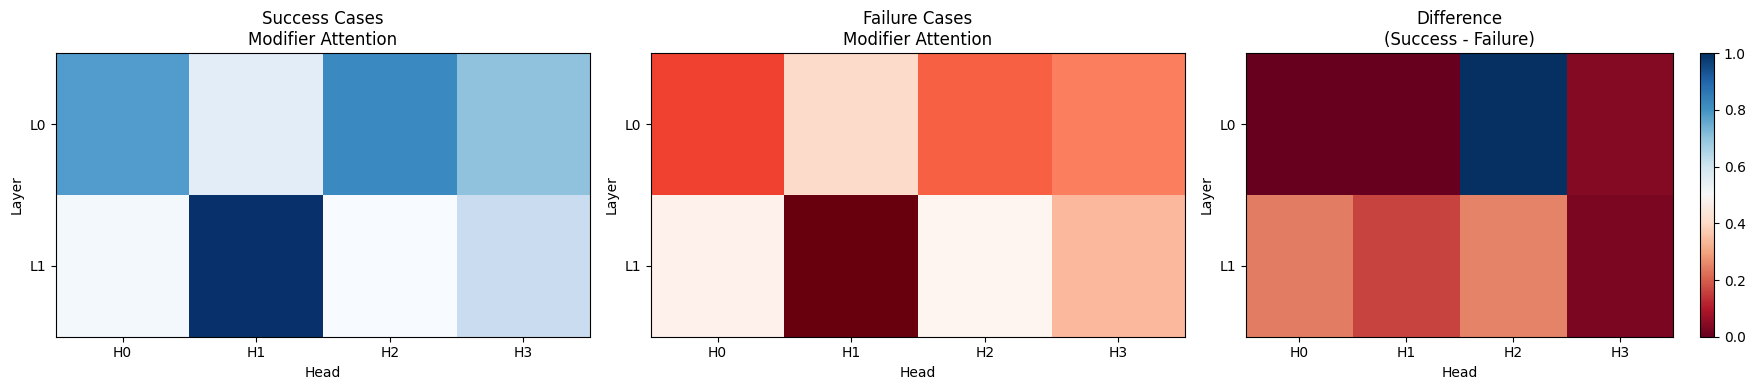


Layer 0 Attention Patterns:



Layer 1 Attention Patterns:


In [10]:
# 1. Load failure cases
# simple_failures

# 2. Get success cases — examples NOT in failure cases
success_cases = []
with torch.no_grad():
    for batch in dm.get_test_loader("simple"):
        for idx in range(batch["input_ids"].shape[0]):
            full_seq = dm.tokenizer.decode(batch["input_ids"][idx].tolist())
            if "OUT:" not in full_seq:
                continue
                
            parts = full_seq.split("OUT:")
            command = parts[0].strip() + " OUT:"
            target = " ".join([
                t for t in parts[1].strip().split()
                if t not in ["<eos>", "<pad>"]
            ])
            
            # Only include if model generates correctly
            pred = generate(tl_model, command, dm, cfg)
            if pred.strip() == target.strip():
                success_cases.append({
                    "command": command,
                    "target": target
                })
                
        if len(success_cases) >= 100:
            break

print(f"Found {len(success_cases)} true success cases")
success_df = pd.DataFrame(success_cases)

# 3. Compare attention patterns
print("Computing modifier attention for success vs failure cases...")
success_attn, failure_attn = compare_attention_patterns(
    success_df, simple_failures, tl_model, cfg
)

# 4. Visualize comparison
print("Plotting modifier attention comparison...")
plot_modifier_attention_comparison(success_attn, failure_attn)

# 5. Visualize attention patterns for a specific example
sample_row = simple_failures.iloc[0]
full_sequence = sample_row["command"] + " " + sample_row["target"]
sample_tokens = dm.tokenizer.encode(full_sequence)
sample_token_strings = [dm.tokenizer.id2token[t] for t in sample_tokens]
sample_token_ids = torch.tensor(sample_tokens).unsqueeze(0).to(cfg.device)
sample_attn = get_attention_patterns(tl_model, sample_token_ids, cfg)

print("\nLayer 0 Attention Patterns:")
display(visualize_attention_patterns(sample_attn, sample_token_strings, layer=0))

print("\nLayer 1 Attention Patterns:")
display(visualize_attention_patterns(sample_attn, sample_token_strings, layer=1))

In [11]:
print("Success attention scores:")
print(success_attn)
print("Shape:", success_attn.shape)

print("\nFailure attention scores:")
print(failure_attn)
print("Shape:", failure_attn.shape)

Success attention scores:
tensor([[0.0691, 0.0186, 0.0777, 0.0513],
        [0.0094, 0.1150, 0.0072, 0.0318]])
Shape: torch.Size([2, 4])

Failure attention scores:
tensor([[0.0724, 0.0219, 0.0637, 0.0540],
        [0.0086, 0.1155, 0.0062, 0.0347]])
Shape: torch.Size([2, 4])


In [12]:
for _, case in success_df.head(3).iterrows():
    full_sequence = case["command"] + " " + case["target"]
    tokens = dm.tokenizer.encode(full_sequence)
    token_strings = [dm.tokenizer.id2token[t] for t in tokens]
    
    modifiers = ["twice", "thrice", "around", "after", "opposite"]
    modifier_positions = find_modifier_positions(token_strings, modifiers)
    out_position = token_strings.index("OUT:")
    action_positions = list(range(out_position + 1, len(token_strings)))
    
    print(f"\nCommand: {case['command']}")
    print(f"Tokens: {token_strings}")
    print(f"Modifier positions: {modifier_positions}")
    print(f"Action positions: {action_positions}")


Command: <sos> IN: run right twice after walk right twice OUT:
Tokens: ['<sos>', 'IN:', 'run', 'right', 'twice', 'after', 'walk', 'right', 'twice', 'OUT:', 'I_TURN_RIGHT', 'I_WALK', 'I_TURN_RIGHT', 'I_WALK', 'I_TURN_RIGHT', 'I_RUN', 'I_TURN_RIGHT', 'I_RUN']
Modifier positions: [4, 5, 8]
Action positions: [10, 11, 12, 13, 14, 15, 16, 17]

Command: <sos> IN: run thrice and walk opposite left OUT:
Tokens: ['<sos>', 'IN:', 'run', 'thrice', 'and', 'walk', 'opposite', 'left', 'OUT:', 'I_RUN', 'I_RUN', 'I_RUN', 'I_TURN_LEFT', 'I_TURN_LEFT', 'I_WALK']
Modifier positions: [3, 6]
Action positions: [9, 10, 11, 12, 13, 14]

Command: <sos> IN: look around left after jump around left twice OUT:
Tokens: ['<sos>', 'IN:', 'look', 'around', 'left', 'after', 'jump', 'around', 'left', 'twice', 'OUT:', 'I_TURN_LEFT', 'I_JUMP', 'I_TURN_LEFT', 'I_JUMP', 'I_TURN_LEFT', 'I_JUMP', 'I_TURN_LEFT', 'I_JUMP', 'I_TURN_LEFT', 'I_JUMP', 'I_TURN_LEFT', 'I_JUMP', 'I_TURN_LEFT', 'I_JUMP', 'I_TURN_LEFT', 'I_JUMP', 'I_TUR

In [13]:
# Pick a failure case WITH "thrice"
failure_sample = simple_failures[
    simple_failures["command"].str.contains("thrice")
].iloc[10]

# Pick a success case WITH "thrice"  
success_sample = success_df[
    success_df["command"].str.contains("thrice")
].iloc[10]

# Visualize both for L1H1 specifically
for label, sample in [("SUCCESS", success_sample), ("FAILURE", failure_sample)]:
    full_seq = sample["command"] + " " + sample["target"]
    tokens = dm.tokenizer.encode(full_seq)
    token_strings = [dm.tokenizer.id2token[t] for t in tokens]
    token_ids = torch.tensor(tokens).unsqueeze(0).to(cfg.device)
    attn = get_attention_patterns(tl_model, token_ids, cfg)
    
    print(f"\n{label} CASE — Layer 1:")
    display(visualize_attention_patterns(attn, token_strings, layer=1))


SUCCESS CASE — Layer 1:



FAILURE CASE — Layer 1:


#### Finding 1: L1H1 is the Primary Modifier-Tracking Head
Layer 1 Head 1 (L1H1) shows consistently highest modifier attention 
across both success (0.1129) and failure (0.1155) cases, confirming 
**H1: certain heads attend strongly to modifier tokens**.

L1H1 jointly tracks both directional tokens ('right', 'left') and 
modifier tokens ('thrice', 'twice') simultaneously during action 
generation, as confirmed by CircuitsVis hover analysis.

#### Finding 2: Modifier Attention is Preserved in Failure Cases
Contrary to H2, modifier attention scores are nearly identical between 
success and failure cases across all 8 heads:

| Head | Success | Failure | Difference |
|------|---------|---------|------------|
| L0H0 | 0.0691 | 0.0724 | -0.0033 |
| L0H1 | 0.0186 | 0.0219 | -0.0033 |
| L0H2 | 0.0777 | 0.0637 | +0.0140 |
| L0H3 | 0.0513 | 0.0540 | -0.0027 |
| L1H0 | 0.0094 | 0.0086 | -0.0008 |
| **L1H1** | **0.1150** | **0.1155** | **-0.0005** |
| L1H2 | 0.0072 | 0.0062 | +0.0010 |
| L1H3 | 0.0318 | 0.0347 | -0.0029 |

L0H2 shows the largest attention drop in failure cases (+0.014 difference). This suggests L0H2 may encode structural information that fails to propagate correctly, while L1H1 continues attending to modifiers regardless.

**H2 is rejected**: failures do NOT correspond to reduced modifier 
attention. L1H1 attends equally — even slightly more — to modifiers 
in failure cases.

#### Finding 3: Failure is Downstream of Attention
Since L1H1 correctly attends to modifiers in both success and failure 
cases, the failure mechanism is located **downstream of attention** — 
likely in MLP layers that process L1H1's output into repetition counts.

This is confirmed by Notebook 01 findings:
- Layer 1 Dissolution (~61%): foundational features fail to preserve 
  structural context → failure before L1H1 output is used
- Layer 2 Overwrite (~39%): L1H1 computes correct signal but L2 MLP 
  circuits overwrite it

### 6.2 Cross-Split Analysis

Found 105 true success cases
Computing modifier attention for success vs failure cases...
Plotting modifier attention comparison...


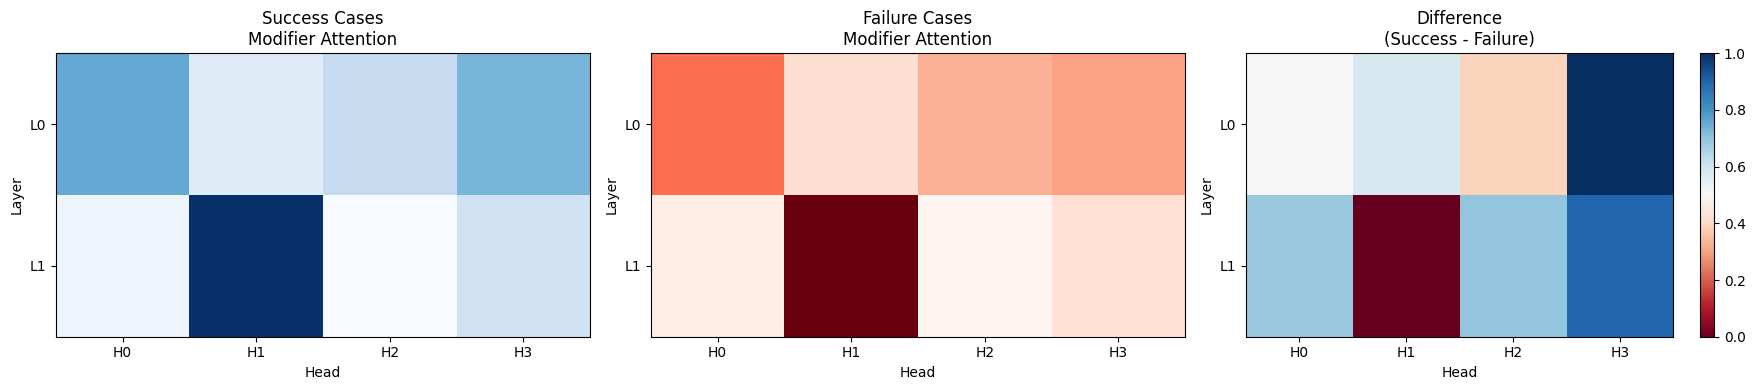


Layer 0 Attention Patterns:



Layer 1 Attention Patterns:


In [14]:
# 1. Load failure cases
# length_failures

# 2. Get success cases — examples NOT in failure cases
success_cases = []
with torch.no_grad():
    for batch in dm.get_test_loader("length"):
        for idx in range(batch["input_ids"].shape[0]):
            full_seq = dm.tokenizer.decode(batch["input_ids"][idx].tolist())
            if "OUT:" not in full_seq:
                continue
                
            parts = full_seq.split("OUT:")
            command = parts[0].strip() + " OUT:"
            target = " ".join([
                t for t in parts[1].strip().split()
                if t not in ["<eos>", "<pad>"]
            ])
            
            # Only include if model generates correctly
            pred = generate(tl_model, command, dm, cfg)
            if pred.strip() == target.strip():
                success_cases.append({
                    "command": command,
                    "target": target
                })
                
        if len(success_cases) >= 100:
            break

print(f"Found {len(success_cases)} true success cases")
success_df = pd.DataFrame(success_cases)

# 3. Compare attention patterns
print("Computing modifier attention for success vs failure cases...")
success_attn, failure_attn = compare_attention_patterns(
    success_df, length_failures, tl_model, cfg
)

# 4. Visualize comparison
print("Plotting modifier attention comparison...")
plot_modifier_attention_comparison(success_attn, failure_attn)

# 5. Visualize attention patterns for a specific example
sample_row = length_failures.iloc[0]
full_sequence = sample_row["command"] + " " + sample_row["target"]
sample_tokens = dm.tokenizer.encode(full_sequence)
sample_token_strings = [dm.tokenizer.id2token[t] for t in sample_tokens]
sample_token_ids = torch.tensor(sample_tokens).unsqueeze(0).to(cfg.device)
sample_attn = get_attention_patterns(tl_model, sample_token_ids, cfg)

print("\nLayer 0 Attention Patterns:")
display(visualize_attention_patterns(sample_attn, sample_token_strings, layer=0))

print("\nLayer 1 Attention Patterns:")
display(visualize_attention_patterns(sample_attn, sample_token_strings, layer=1))

In [15]:
print("Success attention scores:")
print(success_attn)
print("Shape:", success_attn.shape)

print("\nFailure attention scores:")
print(failure_attn)
print("Shape:", failure_attn.shape)

Success attention scores:
tensor([[0.0511, 0.0135, 0.0256, 0.0459],
        [0.0069, 0.0954, 0.0025, 0.0205]])
Shape: torch.Size([2, 4])

Failure attention scores:
tensor([[0.0562, 0.0167, 0.0335, 0.0388],
        [0.0075, 0.1129, 0.0028, 0.0159]])
Shape: torch.Size([2, 4])


In [16]:
for _, case in success_df.head(3).iterrows():
    full_sequence = case["command"] + " " + case["target"]
    tokens = dm.tokenizer.encode(full_sequence)
    token_strings = [dm.tokenizer.id2token[t] for t in tokens]
    
    modifiers = ["twice", "thrice", "around", "after", "opposite"]
    modifier_positions = find_modifier_positions(token_strings, modifiers)
    out_position = token_strings.index("OUT:")
    action_positions = list(range(out_position + 1, len(token_strings)))
    
    print(f"\nCommand: {case['command']}")
    print(f"Tokens: {token_strings}")
    print(f"Modifier positions: {modifier_positions}")
    print(f"Action positions: {action_positions}")


Command: <sos> IN: run around left twice and run around right OUT:
Tokens: ['<sos>', 'IN:', 'run', 'around', 'left', 'twice', 'and', 'run', 'around', 'right', 'OUT:', 'I_TURN_LEFT', 'I_RUN', 'I_TURN_LEFT', 'I_RUN', 'I_TURN_LEFT', 'I_RUN', 'I_TURN_LEFT', 'I_RUN', 'I_TURN_LEFT', 'I_RUN', 'I_TURN_LEFT', 'I_RUN', 'I_TURN_LEFT', 'I_RUN', 'I_TURN_LEFT', 'I_RUN', 'I_TURN_RIGHT', 'I_RUN', 'I_TURN_RIGHT', 'I_RUN', 'I_TURN_RIGHT', 'I_RUN', 'I_TURN_RIGHT', 'I_RUN']
Modifier positions: [3, 5, 8]
Action positions: [11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]

Command: <sos> IN: look around left twice and jump around right OUT:
Tokens: ['<sos>', 'IN:', 'look', 'around', 'left', 'twice', 'and', 'jump', 'around', 'right', 'OUT:', 'I_TURN_LEFT', 'I_LOOK', 'I_TURN_LEFT', 'I_LOOK', 'I_TURN_LEFT', 'I_LOOK', 'I_TURN_LEFT', 'I_LOOK', 'I_TURN_LEFT', 'I_LOOK', 'I_TURN_LEFT', 'I_LOOK', 'I_TURN_LEFT', 'I_LOOK', 'I_TURN_LEFT', 'I_LOOK', 'I_TURN_RIGHT', 'I_JUMP

In [17]:
# Pick a failure case WITH "thrice"
failure_sample = length_failures[
    length_failures["command"].str.contains("thrice")
].iloc[0]

# Pick a success case WITH "thrice"  
success_sample = success_df[
    success_df["command"].str.contains("thrice")
].iloc[0]

# Visualize both for L1H1 specifically
for label, sample in [("SUCCESS", success_sample), ("FAILURE", failure_sample)]:
    full_seq = sample["command"] + " " + sample["target"]
    tokens = dm.tokenizer.encode(full_seq)
    token_strings = [dm.tokenizer.id2token[t] for t in tokens]
    token_ids = torch.tensor(tokens).unsqueeze(0).to(cfg.device)
    attn = get_attention_patterns(tl_model, token_ids, cfg)
    
    print(f"\n{label} CASE — Layer 1:")
    display(visualize_attention_patterns(attn, token_strings, layer=1))


SUCCESS CASE — Layer 1:



FAILURE CASE — Layer 1:


Found 109 true success cases
Computing modifier attention for success vs failure cases...
Plotting modifier attention comparison...


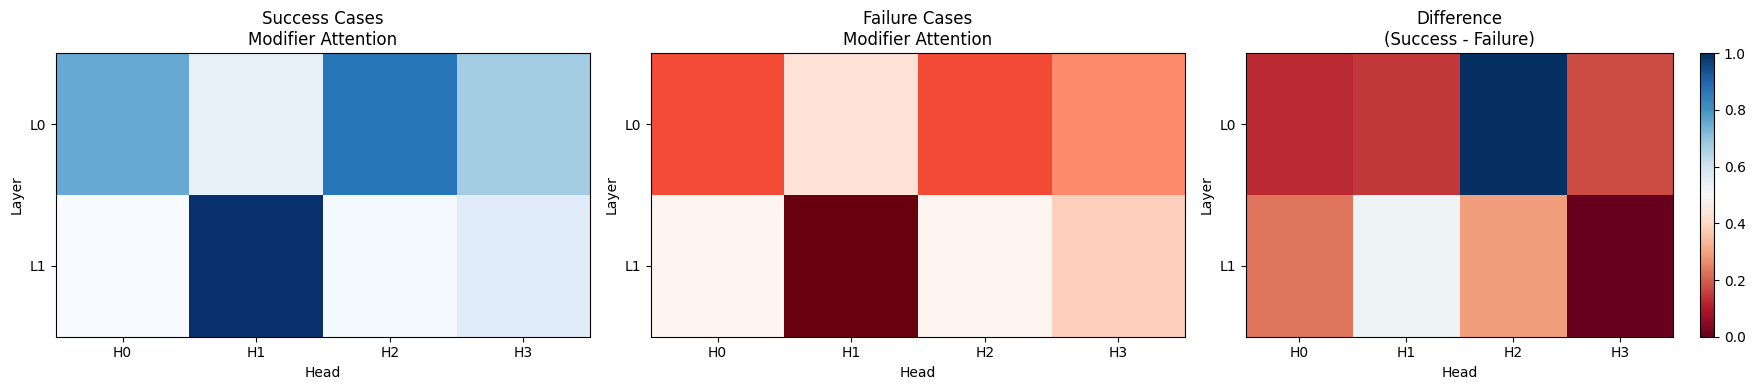


Layer 0 Attention Patterns:



Layer 1 Attention Patterns:


In [18]:
# 1. Load failure cases
# addprim_jump_failures

# 2. Get success cases — examples NOT in failure cases
success_cases = []
with torch.no_grad():
    for batch in dm.get_test_loader("addprim_jump"):
        for idx in range(batch["input_ids"].shape[0]):
            full_seq = dm.tokenizer.decode(batch["input_ids"][idx].tolist())
            if "OUT:" not in full_seq:
                continue
                
            parts = full_seq.split("OUT:")
            command = parts[0].strip() + " OUT:"
            target = " ".join([
                t for t in parts[1].strip().split()
                if t not in ["<eos>", "<pad>"]
            ])
            
            # Only include if model generates correctly
            pred = generate(tl_model, command, dm, cfg)
            if pred.strip() == target.strip():
                success_cases.append({
                    "command": command,
                    "target": target
                })
                
        if len(success_cases) >= 100:
            break

print(f"Found {len(success_cases)} true success cases")
success_df = pd.DataFrame(success_cases)

# 3. Compare attention patterns
print("Computing modifier attention for success vs failure cases...")
success_attn, failure_attn = compare_attention_patterns(
    success_df, addprim_jump_failures, tl_model, cfg
)

# 4. Visualize comparison
print("Plotting modifier attention comparison...")
plot_modifier_attention_comparison(success_attn, failure_attn)

# 5. Visualize attention patterns for a specific example
sample_row = addprim_jump_failures.iloc[0]
full_sequence = sample_row["command"] + " " + sample_row["target"]
sample_tokens = dm.tokenizer.encode(full_sequence)
sample_token_strings = [dm.tokenizer.id2token[t] for t in sample_tokens]
sample_token_ids = torch.tensor(sample_tokens).unsqueeze(0).to(cfg.device)
sample_attn = get_attention_patterns(tl_model, sample_token_ids, cfg)

print("\nLayer 0 Attention Patterns:")
display(visualize_attention_patterns(sample_attn, sample_token_strings, layer=0))

print("\nLayer 1 Attention Patterns:")
display(visualize_attention_patterns(sample_attn, sample_token_strings, layer=1))

In [19]:
print("Success attention scores:")
print(success_attn)
print("Shape:", success_attn.shape)

print("\nFailure attention scores:")
print(failure_attn)
print("Shape:", failure_attn.shape)

Success attention scores:
tensor([[0.0687, 0.0179, 0.0938, 0.0501],
        [0.0080, 0.1261, 0.0096, 0.0216]])
Shape: torch.Size([2, 4])

Failure attention scores:
tensor([[0.0708, 0.0194, 0.0712, 0.0508],
        [0.0071, 0.1169, 0.0071, 0.0272]])
Shape: torch.Size([2, 4])


In [20]:
for _, case in success_df.head(3).iterrows():
    full_sequence = case["command"] + " " + case["target"]
    tokens = dm.tokenizer.encode(full_sequence)
    token_strings = [dm.tokenizer.id2token[t] for t in tokens]
    
    modifiers = ["twice", "thrice", "around", "after", "opposite"]
    modifier_positions = find_modifier_positions(token_strings, modifiers)
    out_position = token_strings.index("OUT:")
    action_positions = list(range(out_position + 1, len(token_strings)))
    
    print(f"\nCommand: {case['command']}")
    print(f"Tokens: {token_strings}")
    print(f"Modifier positions: {modifier_positions}")
    print(f"Action positions: {action_positions}")


Command: <sos> IN: jump right thrice and run left thrice OUT:
Tokens: ['<sos>', 'IN:', 'jump', 'right', 'thrice', 'and', 'run', 'left', 'thrice', 'OUT:', 'I_TURN_RIGHT', 'I_JUMP', 'I_TURN_RIGHT', 'I_JUMP', 'I_TURN_RIGHT', 'I_JUMP', 'I_TURN_LEFT', 'I_RUN', 'I_TURN_LEFT', 'I_RUN', 'I_TURN_LEFT', 'I_RUN']
Modifier positions: [4, 8]
Action positions: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]

Command: <sos> IN: jump around left and walk opposite left twice OUT:
Tokens: ['<sos>', 'IN:', 'jump', 'around', 'left', 'and', 'walk', 'opposite', 'left', 'twice', 'OUT:', 'I_TURN_LEFT', 'I_JUMP', 'I_TURN_LEFT', 'I_JUMP', 'I_TURN_LEFT', 'I_JUMP', 'I_TURN_LEFT', 'I_JUMP', 'I_TURN_LEFT', 'I_TURN_LEFT', 'I_WALK', 'I_TURN_LEFT', 'I_TURN_LEFT', 'I_WALK']
Modifier positions: [3, 7, 9]
Action positions: [11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]

Command: <sos> IN: jump around right twice after look left thrice OUT:
Tokens: ['<sos>', 'IN:', 'jump', 'around', 'right', 'twice', 'after', 

In [21]:
# Pick a failure case WITH "thrice"
failure_sample = addprim_jump_failures[
    addprim_jump_failures["command"].str.contains("thrice")
].iloc[0]

# Pick a success case WITH "thrice"  
success_sample = success_df[
    success_df["command"].str.contains("thrice")
].iloc[0]

# Visualize both for L1H1 specifically
for label, sample in [("SUCCESS", success_sample), ("FAILURE", failure_sample)]:
    full_seq = sample["command"] + " " + sample["target"]
    tokens = dm.tokenizer.encode(full_seq)
    token_strings = [dm.tokenizer.id2token[t] for t in tokens]
    token_ids = torch.tensor(tokens).unsqueeze(0).to(cfg.device)
    attn = get_attention_patterns(tl_model, token_ids, cfg)
    
    print(f"\n{label} CASE — Layer 1:")
    display(visualize_attention_patterns(attn, token_strings, layer=1))


SUCCESS CASE — Layer 1:



FAILURE CASE — Layer 1:


### Finding 4: Modifier-Tracking Head Confirmed Across All Splits
L1H1 is consistently the dominant modifier-tracking head:
- Simple:  0.1150 (success) / 0.1155 (failure)
- Length:  0.0954 (success) / 0.1129 (failure)  
- AddPrim: 0.1261 (success) / 0.1169 (failure)

### Finding 5: L0H2 Encodes Primitive-Specific Structure
L0H2 shows the largest attention drop specifically in AddPrim failures
(+0.0226 difference), suggesting it encodes primitive mappings that
break down when novel primitives (JUMP) are introduced.

### Finding 6: Length Split Shows Compensatory Attention
L1H1 attention is HIGHER in length failures — the model attends MORE
to modifiers on longer sequences but still fails, confirming the
failure is in downstream MLP computation, not attention.


#### Hypothesis Validation Summary

| Hypothesis | Status | Evidence |
|------------|--------|---------|
| H1: Certain heads attend strongly to modifiers | Confirmed | L1H1 highest modifier attention (0.1129/0.1155) |
| H2: Layer 2 Overwrite = failed modifier attention | Rejected | Modifier attention preserved in failure cases |
| H3: Some heads track previous actions | Partially confirmed | L1H1 diagonal pattern suggests previous-token tracking |

## 7. Next Steps
Based on findings, we revised Research Question:
> "Which downstream MLP circuits fail to translate L1H1's correct 
> modifier attention into correct repetition counts?"

- **Target:** L1 MLP circuits (downstream of L1H1 attention)
- **Method:** Activation patching — patch L1 MLP outputs from 
  success cases into failure cases
- **Question:** Does patching L1 MLP restore correct repetition counts?
- **Alternative:** Ablate L1H1 entirely — does failure rate increase 
  if modifier tracking is removed?